In [1]:
from qiskit import __version__
print(__version__)

2.5.2


### "display()" and "array_to_latex()" function

In [2]:
import numpy as np
from qiskit.visualization import array_to_latex

ket_0 = np.array([[1], [0]])
ket_1 = np.array([[0], [1]])

M1 = np.array([[1, 1], [0, 0]])
M2 = np.array([[1, 0], [0, 1]])

M = M1/2 + M2/2

display(array_to_latex(ket_0))
display(array_to_latex(ket_1))
display(array_to_latex(M1))
display(array_to_latex(M2))
display(array_to_latex(M1 @ ket_1))
display(array_to_latex(M1 @ M2))
display(array_to_latex(M @ M))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### "Statevector" class and its "draw()" function with parameters "text", "latex", "latex_source"

In [3]:
from qiskit.quantum_info import Statevector
from numpy import sqrt

u = Statevector([1/sqrt(2), 1/sqrt(2)])
display(u.draw("text"))
display(u.draw("latex"))
print(u.draw("latex_source"))

[0.70710678+0.j,0.70710678+0.j]

<IPython.core.display.Latex object>

\frac{\sqrt{2}}{2} |0\rangle+\frac{\sqrt{2}}{2} |1\rangle


### Statevector class "is_valid()" function

In [4]:
v = Statevector([(1+2j)/3, -2/3])
w = Statevector([1/3, 2/3])

display(v.draw("latex"))
display(w.draw("latex"))

display(v.is_valid())
display(w.is_valid())

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

True

False

### Statevector class "measure()" function to measure a quantum state

In [5]:
for i in range(5):
    print(f"####### measurement {i+1} #######")
    outcome, state = v.measure()
    print(f"Measured {outcome}\nPost-Measurement State: ")
    display(state.draw("latex"))

####### measurement 1 #######
Measured 0
Post-Measurement State: 


<IPython.core.display.Latex object>

####### measurement 2 #######
Measured 1
Post-Measurement State: 


<IPython.core.display.Latex object>

####### measurement 3 #######
Measured 1
Post-Measurement State: 


<IPython.core.display.Latex object>

####### measurement 4 #######
Measured 1
Post-Measurement State: 


<IPython.core.display.Latex object>

####### measurement 5 #######
Measured 1
Post-Measurement State: 


<IPython.core.display.Latex object>

### Statevector class "sample_counts(n)" function to take n number of measurements and "plot_histogram()" function to plot the measurement outcome

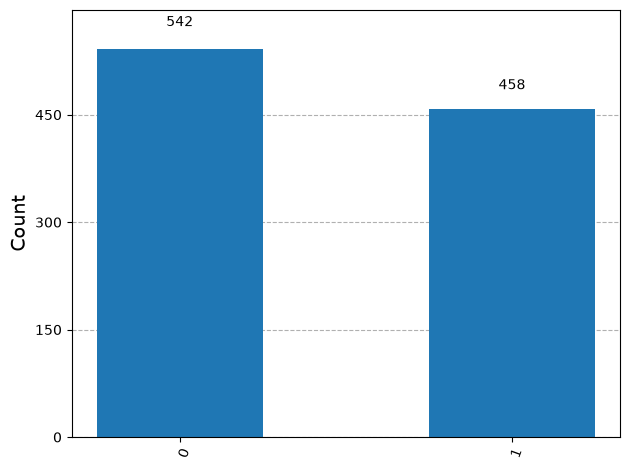

In [6]:
from qiskit.visualization import plot_histogram

statistics = v.sample_counts(1000)
plot_histogram(statistics)

### Creating Operators

In [7]:
from qiskit.quantum_info import Operator

Y = Operator([[0, -1.0j], [1.0j, 0]])
H = Operator([[1/sqrt(2), 1/sqrt(2)], [1/sqrt(2), -1/sqrt(2)]])
S = Operator([[1, 0], [0, 1.0j]])
T = Operator([[1, 0], [0, (1 + 1.0j)/sqrt(2)]])

display(T.draw("latex"))

<IPython.core.display.Latex object>

### Statevector class "evolve(operator or circuit)" function to use an operator on a state vector

In [8]:
v = Statevector([1, 0])

v = v.evolve(H)
v = v.evolve(T)
v = v.evolve(H)
v = v.evolve(S)
v = v.evolve(Y)

display(v.draw("latex"))

<IPython.core.display.Latex object>

### Qiskit "QuantumCircuit" class to create circuits and its "draw(output="mpl")" function to visualize the circuit
    more on quantum circuit later

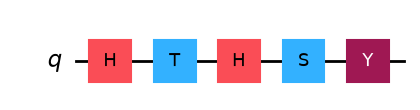

In [9]:
# Basic Preview Of Quantum Circuit
from qiskit import QuantumCircuit

circuit = QuantumCircuit(1)

circuit.h(0)
circuit.t(0)
circuit.h(0)
circuit.s(0)
circuit.y(0)

display(circuit.draw(output="mpl"))

### Operator "from_circuit(circuit_name)" function to get the final composing operator by applying all the gates/operators

In [10]:
display(Operator.from_circuit(circuit).draw("latex"))

<IPython.core.display.Latex object>

In [11]:
ket0 = Statevector([1, 0])
v = ket0.evolve(circuit)
display(v.draw("latex"))

<IPython.core.display.Latex object>

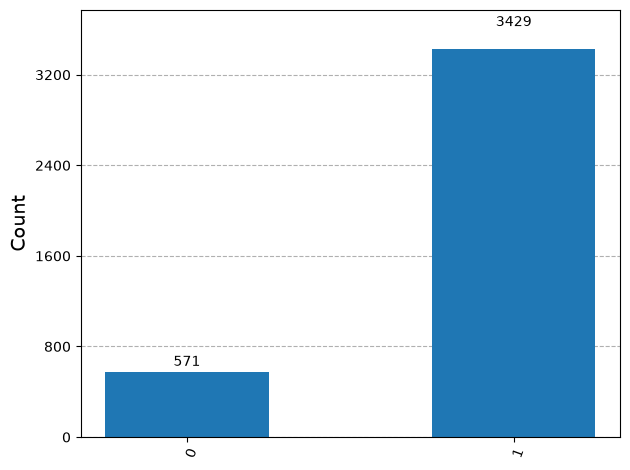

In [12]:
statistics = v.sample_counts(4000)
display(plot_histogram(statistics))

### Statevector .tensor(a) function for tensor product and .from_lebel("0") function to get predefined state vectors

In [13]:
zero = Statevector.from_label("0")
one = Statevector.from_label("1")
psi = zero.tensor(one)
display(psi.draw("latex"))

<IPython.core.display.Latex object>

In [14]:
plus = Statevector.from_label("+")
minus = Statevector.from_label("-")
plus_i = Statevector.from_label("r")
minus_i = Statevector.from_label("l")

display(plus.draw("latex"), minus.draw("latex"), plus_i.draw("latex"), minus_i.draw("latex"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [15]:
phi = plus.tensor(minus_i)
display(phi.draw("latex"))

<IPython.core.display.Latex object>

### We can also use ^ operation to do tensor product

In [16]:
display((plus ^ minus_i).draw("latex"))

<IPython.core.display.Latex object>

### Operator class also have .tensor() method and .from_label() method

In [17]:
H = Operator.from_label("H")
Id = Operator.from_label("I")
X = Operator.from_label("X")

display(H.tensor(Id).draw("latex"))
display(H.tensor(Id).tensor(X).draw("latex"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### We can also use ^ symbol for tensor product in case of operators

In [18]:
display((H ^ Id ^ X).draw("latex"))

<IPython.core.display.Latex object>

In [20]:
display(phi.evolve(H ^ Id).draw("latex"))

<IPython.core.display.Latex object>

### Creating Phi+ bell state

In [22]:
CX = Operator([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]])
phi = plus.tensor(zero)
bell_phi_plus = phi.evolve(CX)

display(bell_phi_plus.draw("latex"))

<IPython.core.display.Latex object>

### Measuring a particular qubit in multiple system i.e. partial measurement

In [24]:
w = Statevector([0, 1, 1, 0, 1, 0, 0, 0]/sqrt(3))
display(w.draw("latex"))

<IPython.core.display.Latex object>

#### Here we can see indexing is from right to left

In [25]:
result, state = w.measure([0])
print(f"Measured: {result} \n State after measurement: ")
display(state.draw("latex"))

Measured: 0 
 State after measurement: 


<IPython.core.display.Latex object>

In [26]:
result, state = w.measure([0, 1])
print(f"Measured: {result} \n State after measurement: ")
display(state.draw("latex"))

Measured: 00 
 State after measurement: 


<IPython.core.display.Latex object>